## 1. Setup

In [19]:
import sys
from pathlib import Path

from scipy.stats import alpha

PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from src.data import load_cached
from src.features import compute_features, FEATURE_COLUMNS
from src.targets import make_targets

plt.style.use("seaborn-v0_8-darkgrid")
sns.set_palette("husl")
%matplotlib inline

## 2. Load ticker

In [20]:
ticker = "AAPL"
df = load_cached(ticker)
print(f"Shape: {df.shape}")
print(f"Date range: {df['date'].min().date()} -> {df['date'].max().date()}")
df.head()

Shape: (2850, 6)
Date range: 2015-01-02 -> 2026-05-04


,date,open,high,low,close,volume
0,2015-01-02,24.671149,24.682224,23.776352,24.214891,212818400
1,2015-01-05,23.984545,24.064280,23.346671,23.532717,257142000
2,2015-01-06,23.596954,23.794075,23.173918,23.534939,263188400
3,2015-01-07,23.743133,23.964618,23.632391,23.864950,160423600
4,2015-01-08,24.192739,24.839473,24.075351,24.781887,237458000


## 3. Compute features + targets

In [21]:
df = compute_features(df)
df = make_targets(df)
df_clean = df.dropna().reset_index(drop=True)

print(f"After processing: {df_clean.shape}")
plt.style.use("seaborn-v0_8-darkgrid")
df_clean.tail()

After processing: (2828, 22)


,date,open,high,low,close,volume,returns,log_returns,close_lag_1,close_lag_5,...,ema_12,ema_26,rsi_14,macd,macd_signal,volatility_21,bb_width,volume_ratio,y_price,y_direction
2823,2026-04-27,266.089996,268.359985,265.070007,267.609985,41466800,-0.012728,-0.012810,271.059998,273.049988,...,267.028064,263.251511,64.430353,3.776553,2.748093,0.016556,0.115533,0.993612,270.709991,1
2824,2026-04-28,272.339996,273.230011,268.660004,270.709991,40018900,0.011584,0.011517,267.609985,266.170013,...,267.594514,263.803991,62.674400,3.790524,2.956579,0.016064,0.103597,0.958261,270.170013,0
2825,2026-04-29,267.549988,271.040009,267.040009,270.170013,30047900,-0.001995,-0.001997,270.709991,273.170013,...,267.990745,264.275548,60.628057,3.715197,3.108303,0.015860,0.099435,0.736748,271.350006,1
2826,2026-04-30,270.500000,276.000000,268.140015,271.350006,91848200,0.004368,0.004358,270.170013,273.429993,...,268.507554,264.799582,61.635629,3.707972,3.228237,0.014830,0.096707,2.117589,280.140015,1
2827,2026-05-01,278.859985,287.220001,278.369995,280.140015,79844600,0.032394,0.031880,271.350006,271.059998,...,270.297164,265.935910,69.310230,4.361253,3.454840,0.016124,0.102841,1.743267,276.829987,0


## 4. Price + Volume chart

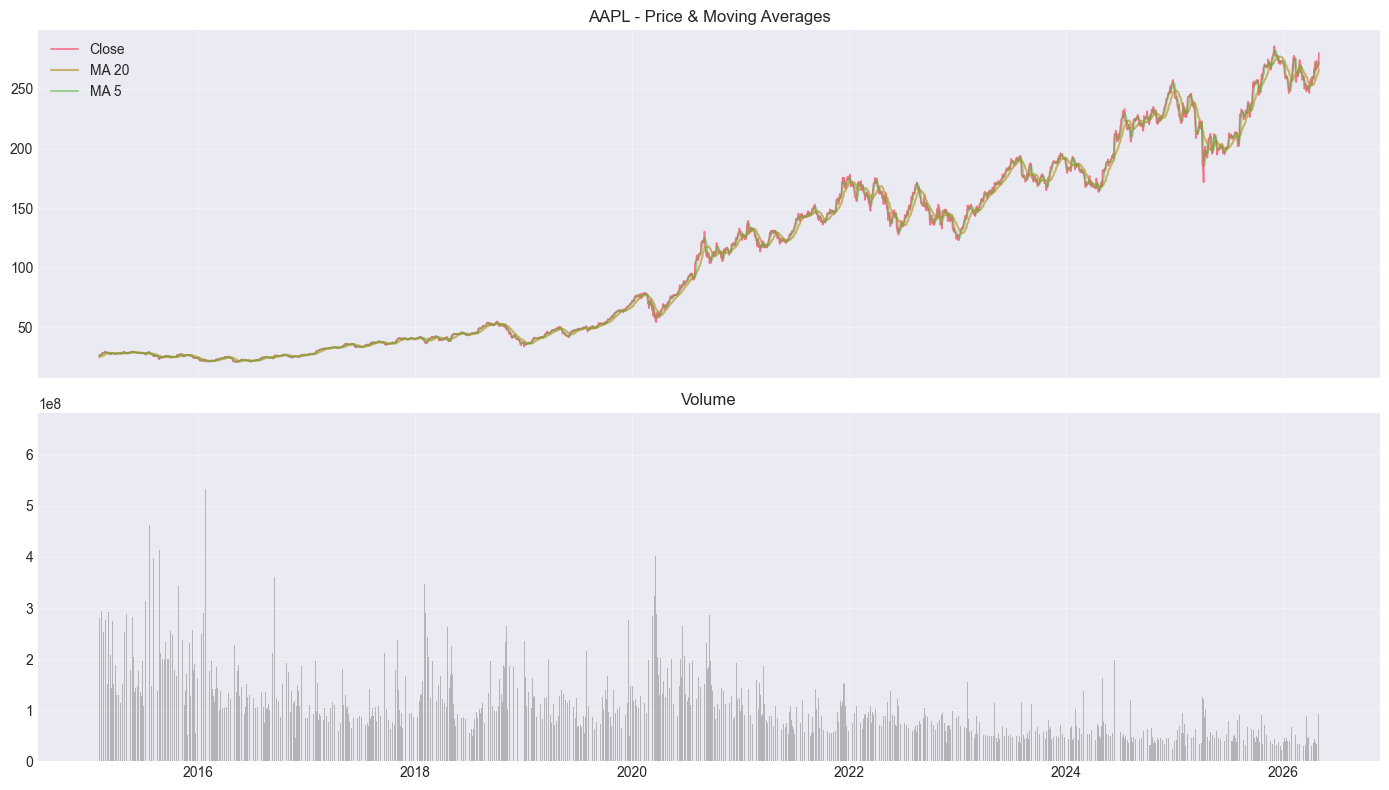

In [22]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

axes[0].plot(df_clean["date"], df_clean["close"], label="Close", linewidth=1.2)
axes[0].plot(df_clean["date"], df_clean["ma_20"], label="MA 20", alpha=0.7)
axes[0].plot(df_clean["date"], df_clean["ma_5"], label="MA 5", alpha=0.5)
axes[0].set_title(f"{ticker} - Price & Moving Averages")
axes[0].legend()

axes[1].bar(df_clean["date"], df_clean["volume"], color="gray", alpha=0.5)
axes[1].set_title("Volume")

plt.tight_layout()
plt.show()

## 5. Returns distribution

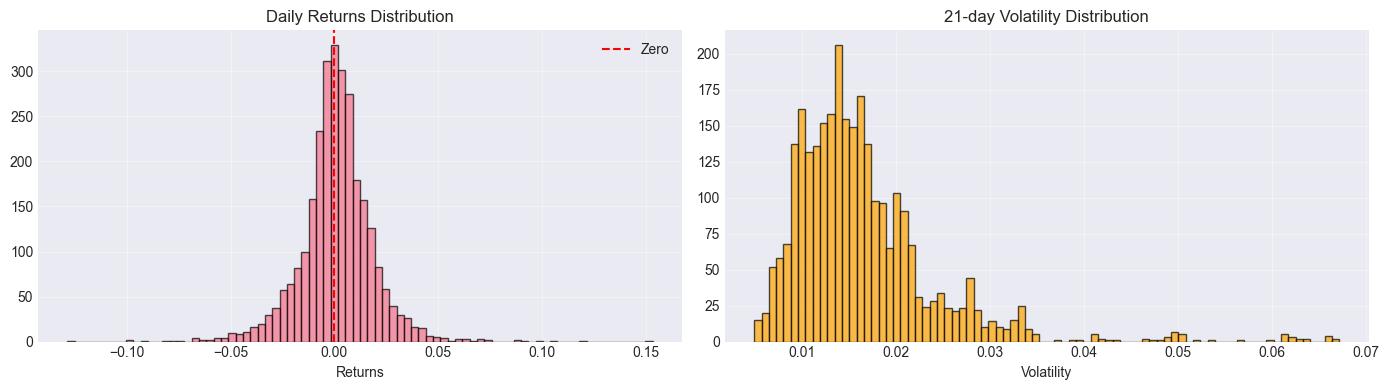

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(df_clean["returns"], bins=80, edgecolor="black", alpha=0.7)
axes[0].axvline(0, color="red", linestyle="--", label="Zero")
axes[0].set_title("Daily Returns Distribution")
axes[0].set_xlabel("Returns")
axes[0].legend()

axes[1].hist(df_clean["volatility_21"], bins=80, edgecolor="black", alpha=0.7, color="orange")
axes[1].set_title("21-day Volatility Distribution")
axes[1].set_xlabel("Volatility")

plt.tight_layout()
plt.show()

## 6. RSI + MACD

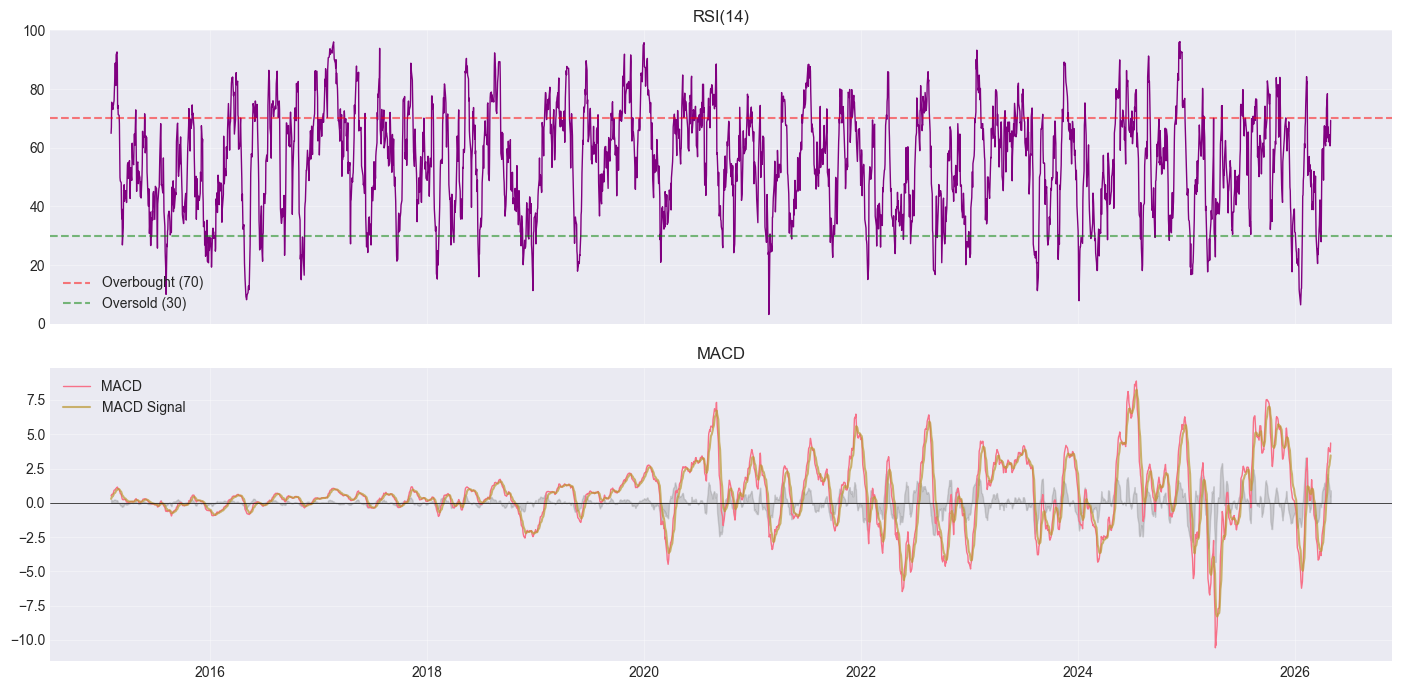

In [24]:
fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

axes[0].plot(df_clean["date"], df_clean["rsi_14"], color="purple", linewidth=1)
axes[0].axhline(70, color="red", linestyle="--", alpha=0.5, label="Overbought (70)")
axes[0].axhline(30, color="green", linestyle="--", alpha=0.5, label="Oversold (30)")
axes[0].set_title("RSI(14)")
axes[0].set_ylim(0, 100)
axes[0].legend()

axes[1].plot(df_clean["date"], df_clean["macd"], label="MACD", linewidth=1)
axes[1].plot(df_clean["date"], df_clean["macd_signal"], label="MACD Signal", alpha=0.7)
axes[1].axhline(0, color="black", linewidth=0.5)
axes[1].fill_between(df_clean["date"], df_clean["macd"] - df_clean["macd_signal"], 0, alpha=0.3, color="gray")
axes[1].set_title("MACD")
axes[1].legend()

plt.tight_layout()
plt.show()

## 7. Correlation matrix

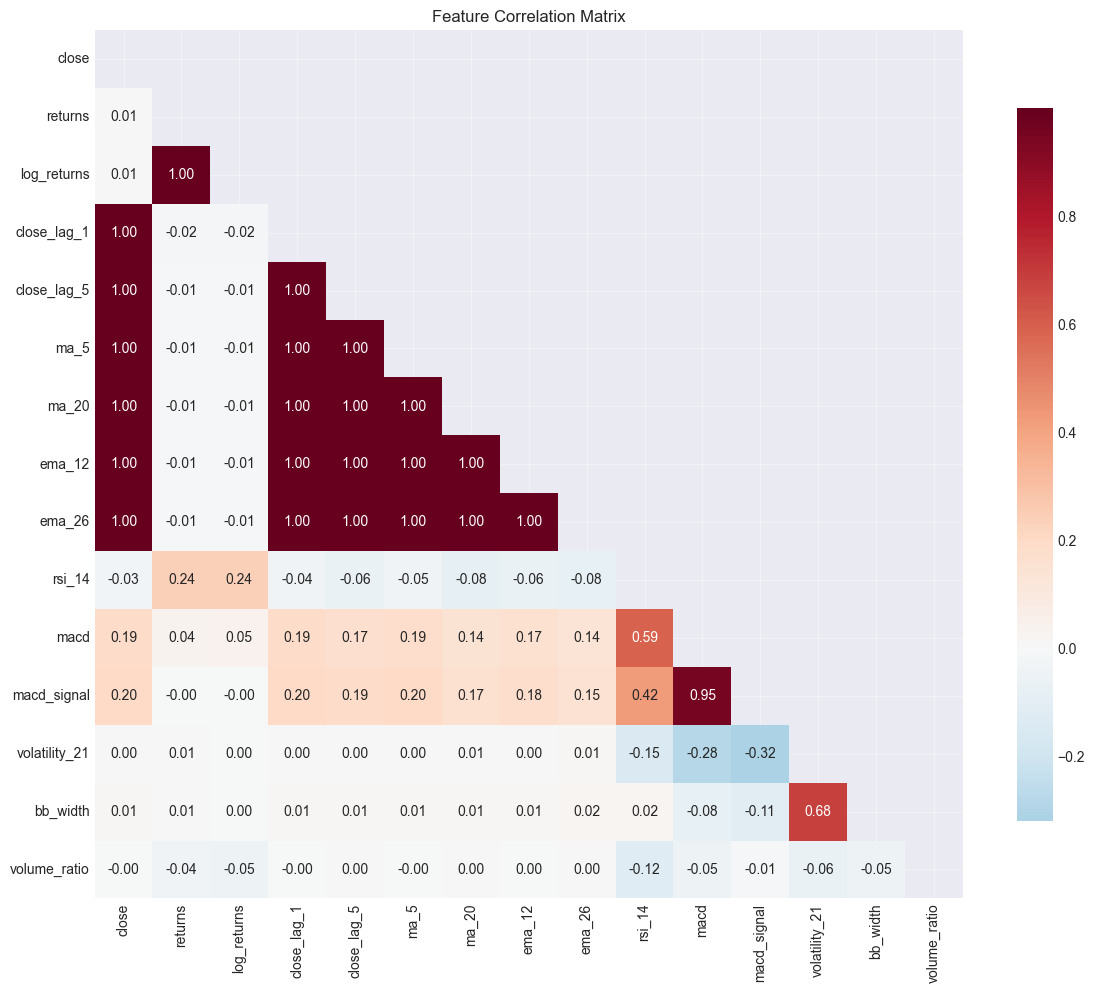

In [25]:
plt.figure(figsize=(12, 10))
corr = df_clean[FEATURE_COLUMNS].corr()

mask = np.triu(np.ones_like(corr, dtype=bool))

sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="RdBu_r", center=0,
            square=True, cbar_kws={"shrink": 0.8})
plt.title("Feature Correlation Matrix")
plt.tight_layout()
plt.show()

## 8. Target distribution + statistics

In [26]:
print("=" * 50)
print("Target distribution (y_direction)")
print("=" * 50)
print(df_clean["y_direction"].value_counts())
print()
print(f"Up:   {(df_clean['y_direction']==1).mean():.2%}")
print(f"Down: {(df_clean['y_direction']==0).mean():.2%}")

print("\n" + "=" * 50)
print("Statistics summary")
print("=" * 50)
print(df_clean[FEATURE_COLUMNS + ["y_price"]].describe().T[["mean", "std", "min", "max"]])

Target distribution (y_direction)
y_direction
1    1498
0    1330
Name: count, dtype: int64

Up:   52.97%
Down: 47.03%

Statistics summary
                     mean        std        min         max
close          111.389904  77.630878  20.584814  285.922455
returns          0.001000   0.018062  -0.128647    0.153289
log_returns      0.000837   0.018047  -0.137708    0.142618
close_lag_1    111.300135  77.582439  20.584814  285.922455
close_lag_5    110.954363  77.419067  20.584814  285.922455
ma_5           111.214196  77.513937  20.943925  282.333820
ma_20          110.567266  77.133837  21.386588  277.254568
ema_12         110.913256  77.308169  21.393519  278.006543
ema_26         110.323897  76.953329  21.874128  274.575086
rsi_14          55.246757  17.895637   3.180114   96.163009
macd             0.589359   2.356452 -10.583946    8.886668
macd_signal      0.584797   2.201507  -8.299755    8.256341
volatility_21    0.016393   0.007783   0.004904    0.067185
bb_width         0.11